ARTI308 - Machine Learning

# Lab 4: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

In [5]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [10]:
pd.set_option("display.max_columns", None)

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

df = pd.read_csv(url, names=columns, na_values='?')

df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


### 2.1 Check Data Types

We check the data types of each column to ensure they match the expected numeric format.

Since the Heart Disease dataset contains medical measurements and categorical values encoded as numbers, all columns should be numeric (int64 or float64).

In [7]:
df.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

We observe that some columns are stored as object type.
`Date` and `Amount` may not yet be in the correct format.
Incorrect data types can prevent proper calculations and time-based analysis.

### 2.2 Convert Incorrect Data Types

In this dataset, most columns are already in correct numeric format.  
No conversion is required because the dataset does not contain Date or currency columns.

We will only verify that all columns have appropriate numeric data types.

In [8]:
# Check and confirm correct data types for Heart Disease dataset
df.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

### 3.1 Detect Missing Values

We check each column for missing values using the isnull().sum() function.  
In the Heart Disease dataset, some columns such as `ca` and `thal` may contain missing values.

In [12]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

The output shows whether any column contains missing values.
If all values are zero, the dataset is complete.
If any column contains missing values, we must handle them.

### 3.2 Demonstration: Introduce Artificial Missing Values

For learning purposes, we will introduce artificial missing values into the Heart Disease dataset.

We will create a copy of the dataset and insert missing values into the `chol` column to demonstrate how to handle them.

In [13]:
# Create a copy of the dataset
df_missing = df.copy()

# Introduce artificial missing values in the 'chol' column
df_missing.loc[0:5, 'chol'] = np.nan

# Check missing values
df_missing.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        6
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Now the 'chol' column contains artificial missing values introduced for demonstration purposes.

In [15]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (303, 14)
After removing some values:  (303, 14)


In [14]:
df_missing.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,NaN,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,NaN,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,NaN,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,NaN,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,NaN,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,NaN,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


### Strategy 1: Remove Records

This strategy removes rows that contain missing values using the dropna() function.

This method is useful when the number of missing rows is small and removing them does not significantly affect the dataset.

In [16]:
df_removed = df_missing.dropna()
df_removed.shape

(291, 14)

In [17]:
df_removed.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

The dataset now has fewer rows because rows containing missing values in the 'chol' column were removed.

This method is acceptable when the number of missing values is small, but removing too many rows may result in loss of important information.

### Strategy 2: Mean Imputation

In this strategy, missing values are replaced with the mean (average) of the column.

We will replace missing values in the 'chol' column with the mean cholesterol value.

In [18]:
df_missing.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,NaN,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,NaN,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,NaN,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,NaN,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,NaN,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,NaN,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [19]:
df_imputed_mean = df_missing.copy()

# Fill missing values in 'chol' with mean
df_imputed_mean['chol'].fillna(df_imputed_mean['chol'].mean(), inplace=True)

# Verify no missing values remain
df_imputed_mean.isnull().sum()

C:\Users\qrnby\AppData\Local\Temp\ipykernel_18144\1678727151.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_imputed_mean['chol'].fillna(df_imputed_mean['chol'].mean(), inplace=True)


age         0
sex         0
cp          0
trestbps    0
chol        6
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [20]:
df_imputed_mean.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,NaN,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,NaN,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,NaN,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,NaN,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,NaN,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,NaN,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


Missing values in the 'chol' column have been replaced with the mean cholesterol value.

This method preserves the dataset size but may reduce variability and is sensitive to outliers.

### Strategy 3: Median Imputation

In this strategy, missing values are replaced with the median of the column.

The median is more robust to outliers than the mean and is preferred for skewed data.

We will replace missing values in the 'chol' column using the median cholesterol value.

In [21]:
df_imputed_median = df_missing.copy()

# Fill missing values using median
df_imputed_median['chol'] = df_imputed_median['chol'].fillna(df_imputed_median['chol'].median())

# Verify no missing values remain
df_imputed_median.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [30]:
df_imputed_median.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5220.745,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,5220.745,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,5220.745,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,5220.745,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,5220.745,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,5220.745,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.000,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.000,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.000,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.000,102


Missing values in the 'chol' column have been replaced with the median cholesterol value.

Median imputation is more robust to outliers and preserves the dataset size.

## 4. Handling Outliers

Outliers are extreme values that can affect machine learning models.

We will use a boxplot to detect outliers in the 'chol' (cholesterol) column.

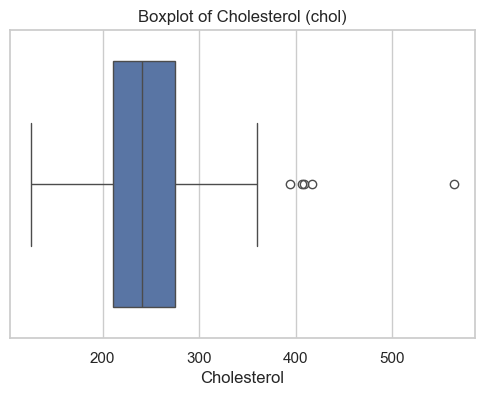

In [22]:
plt.figure(figsize=(6,4))

# Boxplot for cholesterol column
sns.boxplot(x=df['chol'])

plt.title("Boxplot of Cholesterol (chol)")
plt.xlabel("Cholesterol")

plt.show()

The boxplot shows the distribution of cholesterol values.  
Points outside the whiskers represent potential outliers.

### Detect Outliers using IQR

We use the Interquartile Range (IQR) method to detect outliers in the 'chol' column.

Outliers are values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR.

In [23]:
# Calculate Q1 and Q3 for cholesterol
Q1 = df['chol'].quantile(0.25)
Q3 = df['chol'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define lower and upper bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['chol'] < lower) | (df['chol'] > upper)]

# Show outliers
outliers.head(15)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
48,65.0,0.0,3.0,140.0,417.0,1.0,2.0,157.0,0.0,0.8,1.0,1.0,3.0,0
121,63.0,0.0,4.0,150.0,407.0,0.0,2.0,154.0,0.0,4.0,2.0,3.0,7.0,4
152,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,0
173,62.0,0.0,4.0,140.0,394.0,0.0,2.0,157.0,0.0,1.2,2.0,0.0,3.0,0
181,56.0,0.0,4.0,134.0,409.0,0.0,2.0,150.0,1.0,1.9,2.0,2.0,7.0,2


Outliers in the 'chol' column were detected using the IQR method.

Values below the lower bound or above the upper bound are considered outliers.

### Remove Outliers

We remove rows where the 'chol' value is outside the acceptable IQR range.

In [24]:
# Remove outliers from chol column
df_no_outliers = df[(df['chol'] >= lower) & (df['chol'] <= upper)]

# Print shapes
print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (303, 14)
After removing outliers: (298, 14)


Rows with cholesterol values outside the IQR range were removed.

This reduces the effect of extreme values but may also remove rare valid observations.

### Capping Outliers (Percentile Method)

Instead of removing outliers, we replace extreme cholesterol values with percentile limits.

In [25]:
# Define percentile caps for chol
lower_cap = df['chol'].quantile(0.05)
upper_cap = df['chol'].quantile(0.95)

# Create copy of dataset
df_capped = df.copy()

# Apply capping
df_capped['chol'] = df_capped['chol'].clip(lower_cap, upper_cap)

# Check result
df_capped[['chol']].describe()

,chol
count,303.000000
mean,245.211221
std,43.267013
min,175.100000
25%,211.000000
50%,241.000000
75%,275.000000
max,326.900000


## 5. Data Transformation – Normalization

Normalization scales numerical features to a similar range.  
This ensures that no feature dominates the model due to larger numerical values.

In the Heart Disease dataset, we apply normalization to features such as age, chol, trestbps, and thalach.


### Min-Max Normalization

Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

This method preserves the original distribution and relative ordering of values.

We apply Min-Max normalization to numerical features such as 'age', 'chol', 'trestbps', and 'thalach'.

In [26]:
df[['age', 'chol']].head()

,age,chol
0,63.0,233.0
1,67.0,286.0
2,67.0,229.0
3,37.0,250.0
4,41.0,204.0


In [ ]:
!pip install scikit-learn

In [30]:
from sklearn.preprocessing import MinMaxScaler

# Select columns to normalize
cols_to_normalize = ['age', 'chol', 'trestbps', 'thalach']

# Create scaler
scaler = MinMaxScaler()

# Create copy
df_normalized = df.copy()

# Apply normalization
df_normalized[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

# Show result
df_normalized[cols_to_normalize].head()

,age,chol,trestbps,thalach
0,0.708333,0.244292,0.481132,0.603053
1,0.791667,0.365297,0.622642,0.282443
2,0.791667,0.235160,0.245283,0.442748
3,0.166667,0.283105,0.339623,0.885496
4,0.250000,0.178082,0.339623,0.770992


After applying Min-Max normalization, numerical features such as age, chol, trestbps, and thalach were scaled to the range [0, 1].

Normalization preserves the relative relationships between values while ensuring all features are on the same scale, which improves machine learning performance.

### Z-Score Normalization (Standardization)

Z-score standardization transforms numerical features so that:

- The mean of each feature becomes 0  
- The standard deviation becomes 1  

We apply standardization to features such as age, chol, trestbps, and thalach.

In [31]:
from sklearn.preprocessing import StandardScaler

# Select columns to standardize
cols_to_standardize = ['age', 'chol', 'trestbps', 'thalach']

# Create scaler
scaler = StandardScaler()

# Create copy
df_standardized = df.copy()

# Apply Z-score normalization
df_standardized[cols_to_standardize] = scaler.fit_transform(df[cols_to_standardize])

# Show result
df_standardized[cols_to_standardize].head()

,age,chol,trestbps,thalach
0,0.948726,-0.264900,0.757525,0.017197
1,1.392002,0.760415,1.611220,-1.821905
2,1.392002,-0.342283,-0.665300,-0.902354
3,-1.932564,0.063974,-0.096170,1.637359
4,-1.489288,-0.825922,-0.096170,0.980537


After applying Z-score standardization, the numerical features such as age, chol, trestbps, and thalach are centered around 0.

Values above the original mean become positive, and values below the mean become negative.

The standard deviation of each feature becomes approximately 1, meaning the spread of the data is standardized.

This transformation preserves the distribution shape while ensuring all features are on the same scale.

Standardization is especially useful for machine learning algorithms such as:
- Linear Regression  
- Support Vector Machines (SVM)  
- Principal Component Analysis (PCA)  

Because these models perform better when features are centered and scaled consistently.

### Check Correlation Before Applying PCA

We check whether numerical features in the Heart Disease dataset are correlated.

If features are strongly correlated, PCA can reduce dimensionality by combining them into fewer components while preserving important information.

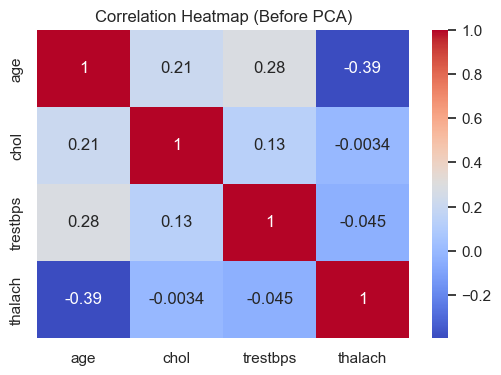

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
cols_for_pca = ['age', 'chol', 'trestbps', 'thalach']

# Plot correlation heatmap
plt.figure(figsize=(6,4))

sns.heatmap(df_standardized[cols_for_pca].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The heatmap shows the correlation between the numerical features in the Heart Disease dataset:

- The diagonal values are 1 because each feature is perfectly correlated with itself.
- The off-diagonal values represent the correlation between different features such as age, chol, trestbps, and thalach.

Correlation values close to 0 indicate weak or no linear relationship between features, while values closer to 1 or -1 indicate stronger relationships.

If features are strongly correlated, PCA can reduce redundancy by combining them into fewer components.

In this dataset, most correlations are moderate or weak, so PCA may provide limited dimensionality reduction. Therefore, PCA is applied mainly for demonstration and learning purposes.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique used to reduce the number of features while preserving the most important information.

In the Heart Disease dataset, PCA transforms the original numerical features such as age, chol, trestbps, and thalach into new features called principal components.

These principal components:

- Are linear combinations of the original features  
- Are uncorrelated with each other  
- Capture the variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance while being orthogonal (independent) to PC1.

This allows us to reduce dimensionality while retaining most of the important information and simplifying the dataset for machine learning models.

### Visual Intuition

In the Heart Disease dataset, we have multiple features such as age, chol, trestbps, and thalach.

These features may contain overlapping information.

PCA finds new directions (principal components) that capture the maximum variance in the data.

The first principal component (PC1) captures the largest amount of variance.

The second principal component (PC2) captures the next largest variance and is independent of PC1.

If most of the variance is captured by PC1 and PC2, we can reduce the dataset from multiple features to fewer components while preserving most of the important information.

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

# Select standardized features
cols_for_pca = ['age', 'chol', 'trestbps', 'thalach']

X = df_standardized[cols_for_pca]

# Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Show explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Create DataFrame for PCA result
df_pca = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2']
)

# Show first rows
df_pca.head()

Explained Variance Ratio: [0.39561462 0.26049374]


,PC1,PC2
0,0.871201,0.043909
1,2.795591,-0.201599
2,0.962443,-1.245378
3,-2.115731,1.295646
4,-1.801812,0.258208


The Explained Variance Ratio shows how much variance is captured by each principal component.

Higher values indicate that the component preserves more information from the original features.

If the first few components capture most of the variance, PCA successfully reduces dimensionality while retaining important information.

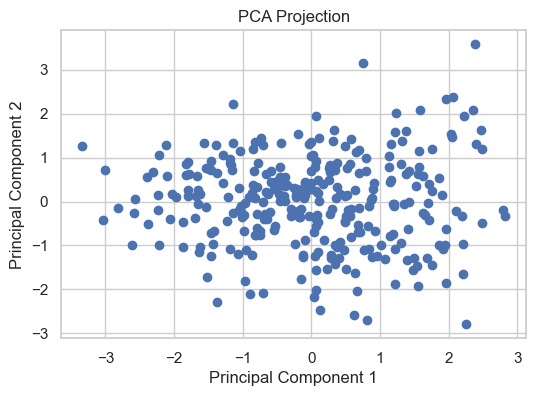

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one patient from the Heart Disease dataset.

The horizontal axis represents Principal Component 1 (PC1), and the vertical axis represents Principal Component 2 (PC2).

These principal components are new features created by PCA from the original features (age, chol, trestbps, and thalach).

PC1 captures the largest amount of variance in the data, while PC2 captures the second largest amount.

This plot shows how PCA reduces the dataset into fewer dimensions while preserving most of the important information.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of lab 4.